In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/cleaned_house_data.csv")
print(df.shape)
print(df.head())

(20467, 21)
      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0  221900.0         3       1.00         1180      5650     1.0           0   
1  538000.0         3       2.25         2570      7242     2.0           0   
2  180000.0         2       1.00          770     10000     1.0           0   
3  604000.0         4       3.00         1960      5000     1.0           0   
4  510000.0         3       2.00         1680      8080     1.0           0   

   view  condition  grade  ...  sqft_basement  yr_built      lat     long  \
0     0          3      7  ...              0      1955  47.5112 -122.257   
1     0          3      7  ...            400      1951  47.7210 -122.319   
2     0          3      6  ...              0      1933  47.7379 -122.233   
3     0          5      7  ...            910      1965  47.5208 -122.393   
4     0          3      8  ...              0      1987  47.6168 -122.045   

   sqft_living15  sqft_lot15  house_age  price_per

In [20]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (16373, 20)
Test set: (4094, 20)


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

#Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

lr_predictions = lr.predict(X_test_scaled)
rf_predictions = rf.predict(X_test)
gb_predictions = gb.predict(X_test)


In [23]:
#MAE — Mean Absolute Error
#RMSE — Root Mean Squared Error
#R² Score
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    print(f"\n{name}")
    print(f"MAE:  ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"R²:   {r2:.4f}")

evaluate_model("Linear Regression", y_test, lr_predictions)
evaluate_model("Random Forest", y_test, rf_predictions)
evaluate_model("Gradient Boosting", y_test, gb_predictions)


Linear Regression
MAE:  $43,494
RMSE: $61,888
R²:   0.9080

Random Forest
MAE:  $2,731
RMSE: $7,464
R²:   0.9987

Gradient Boosting
MAE:  $12,707
RMSE: $17,913
R²:   0.9923


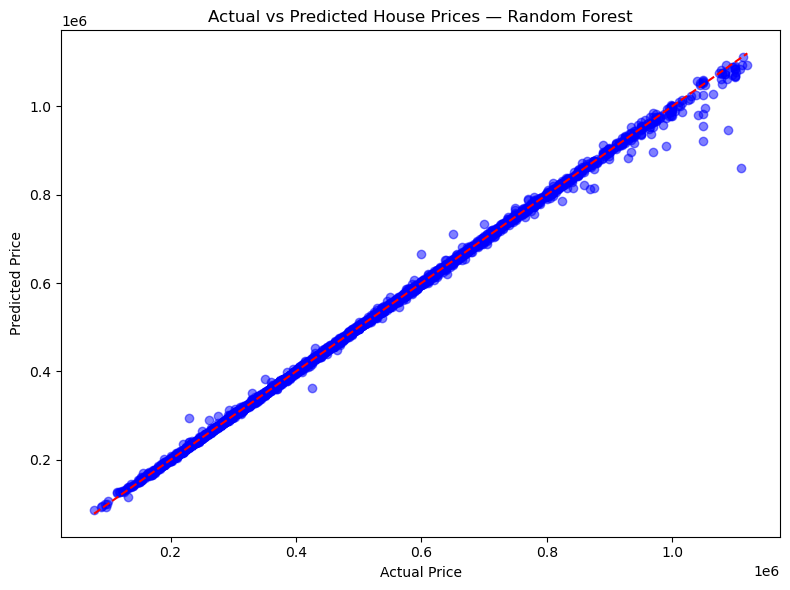

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices — Random Forest")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

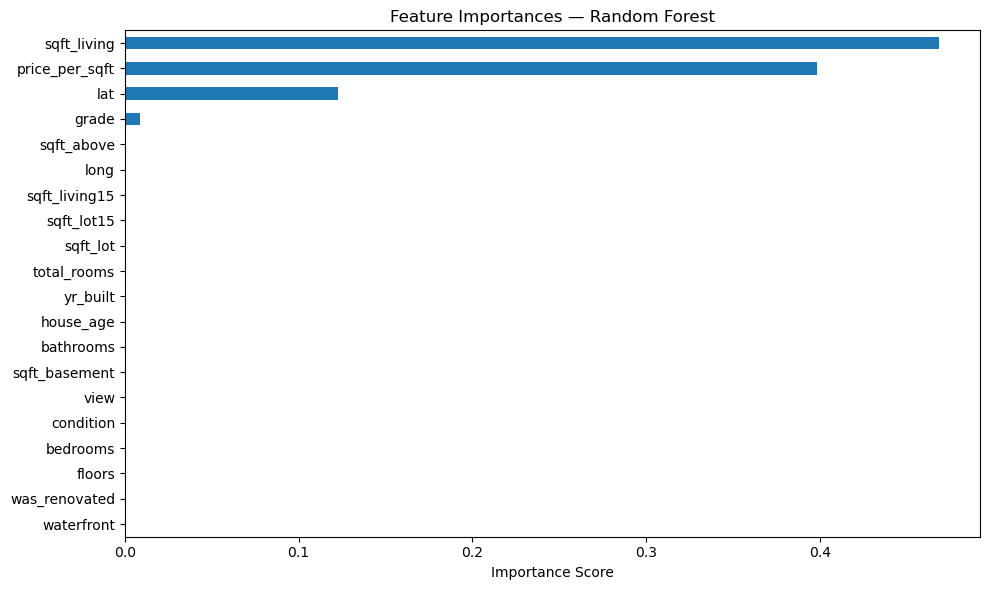

In [25]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importances.png")
plt.show()

In [27]:
#obseravtions:
# Random Forest achieved R² of 0.9987 — almost perfect but possibly overfitting
# price_per_sqft was the most important feature, confirming EDA findings
# Ensemble methods massively outperformed simple linear regression
# Feature engineering in 02_cleaning directly contributed to model performance